# Interactive Data Analysis with Kepler/K2 and TESS

__Benjamin Pope__

_University of Queensland_ 

<img src="qrcode_github.com.png" alt="QR Code" style="width: 300px; display:block; margin:auto"/> -->

In [43]:
# This is going to be an interactive lecture using Jupyter! 
# So let's import things!

import numpy as np 
import matplotlib.pyplot as plt

import lightkurve
from k2sc.standalone import k2sc_lc

from astropy.timeseries import LombScargle, BoxLeastSquares
import astropy.units as u

import warnings; warnings.simplefilter('ignore')

%matplotlib inline


# Kepler data

The Kepler Space Telescope revolutionised exoplanetary science by providing high-precision photometry of hundreds of thousands of stars. The data is publicly available and has been used to discover thousands of exoplanets.



While the mission science team originally aimed to keep their data proprietary and analyse it in-house, after a brief period they pivoted to an open-source model with data hosted on [MAST](https://archive.stsci.edu/kepler/), and many teams developed open-source software to analyse the data. This is what I did my DPhil on!

<!-- <img src="hubble.png" alt="Hubble's Data" style="width: 500px;"/> -->


We're going to interactively explore data from Kepler to see how we would discover planets, stellar variability, and correct for instrumental systematics.

In [2]:
# download Kepler-10 data
target = 'Kepler-10'
search = lightkurve.search_targetpixelfile(target,exptime=60) # get 1 minute cadence data
search 


#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,Kepler Quarter 02,2009,Kepler,60,kplr011904151,0.0
1,Kepler Quarter 03,2009,Kepler,60,kplr011904151,0.0
2,Kepler Quarter 03,2009,Kepler,60,kplr011904151,0.0
3,Kepler Quarter 03,2009,Kepler,60,kplr011904151,0.0
4,Kepler Quarter 07,2010,Kepler,60,kplr011904151,0.0
5,Kepler Quarter 07,2010,Kepler,60,kplr011904151,0.0
6,Kepler Quarter 07,2010,Kepler,60,kplr011904151,0.0
7,Kepler Quarter 06,2010,Kepler,60,kplr011904151,0.0
8,Kepler Quarter 06,2010,Kepler,60,kplr011904151,0.0


<Axes: title={'center': 'Target ID: 11904151, Cadence: 210580'}, xlabel='Pixel Column Number', ylabel='Pixel Row Number'>

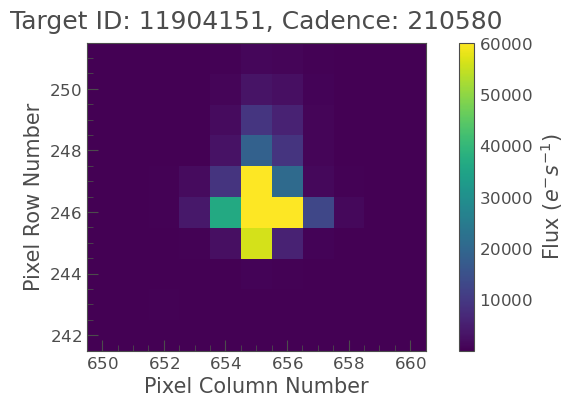

In [3]:
tpf = search[1].download()
tpf.plot()

Cool! We can make this into a light curve the simplest way possible: define a pixel mask, and sum the flux in the pixels.

Let's use the default mask from the pipeline.

<Axes: title={'center': 'Target ID: 11904151, Cadence: 210580'}, xlabel='Pixel Column Number', ylabel='Pixel Row Number'>

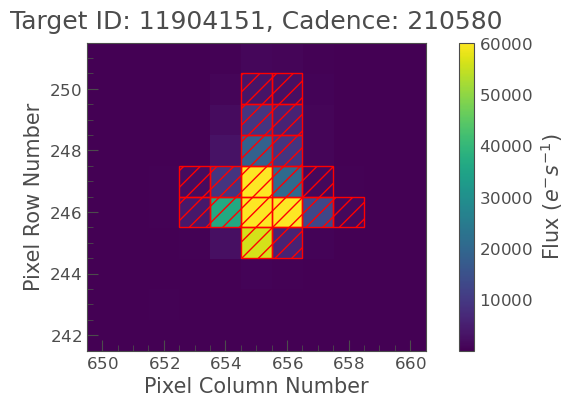

In [4]:
tpf.plot(aperture_mask = 'pipeline')

<Axes: xlabel='Time - 2454833 [BKJD days]', ylabel='Normalized Flux'>

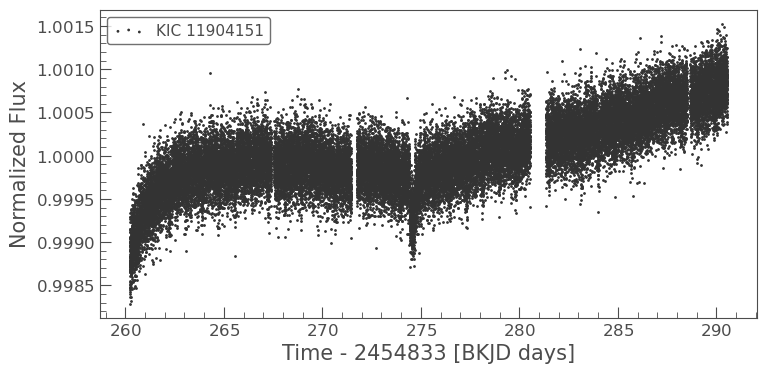

In [5]:
# let's sum this to make a lightcurve
lc = tpf.to_lightcurve(aperture_mask = 'pipeline').normalize().remove_nans()
lc = lc[lc.quality==0]
lc.scatter()

<Axes: xlabel='Time - 2454833 [BKJD days]', ylabel='Normalized Flux'>

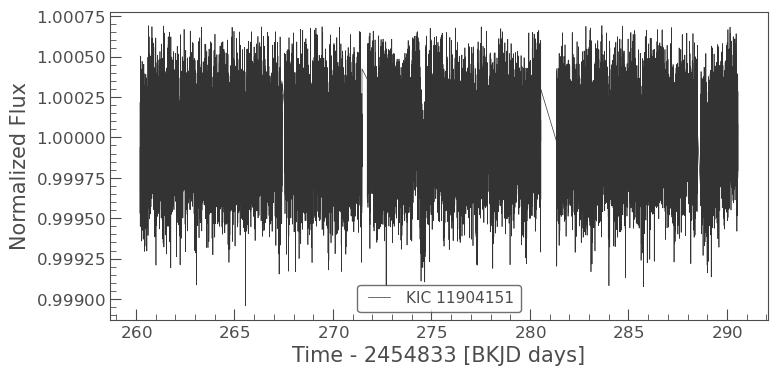

In [6]:
# what about that long-term trend?
flat = lc.flatten(window_length=2*24*60+1).remove_outliers(sigma_upper=3,sigma_lower=100)
flat.plot()

900.0 s


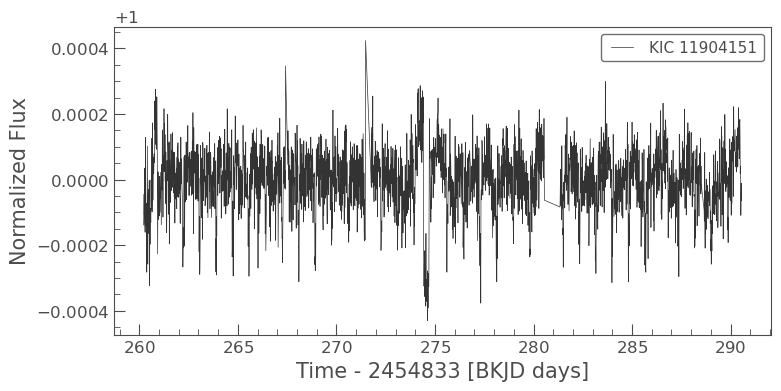

In [7]:
# it's hard to see what's going on here - can we bin it to a coarser cadence?
our_lc = flat.bin(0.25*u.hour).remove_nans()
our_lc.plot()

print((0.25*u.hour).to(u.s))

In [8]:
# box-least-squares fits a periodic signal of dips to the light curve

bls = BoxLeastSquares(our_lc.time, our_lc.flux, dy=our_lc.flux_err)

periods = np.linspace(0.3, 1.5, 1000)*u.day
durations = np.linspace(0.05, 0.2, 10)*u.day
periodogram = bls.power(periods, durations)

best_period = periods[np.argmax(periodogram.depth_snr.value)]
best_duration = periodogram.duration[np.argmax(periodogram.depth_snr.value)]
best_depth = periodogram.depth[np.argmax(periodogram.depth_snr.value)]
t0 = periodogram.transit_time[np.argmax(periodogram.depth_snr.value)]

Text(0.8869369369369369, 40.83467531875844, 'Best period: 0.8369 days')

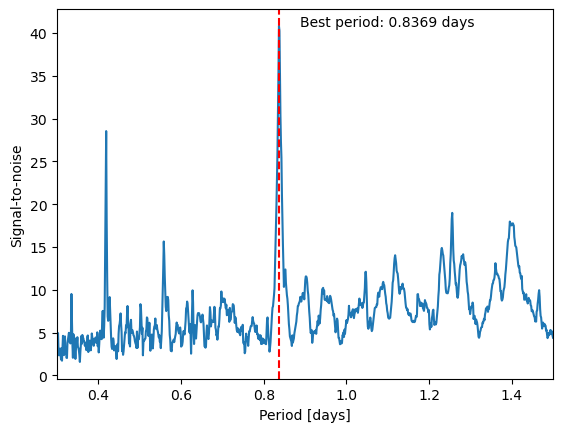

In [9]:
plt.plot(periodogram.period.value,periodogram.depth_snr.value)
plt.xlabel('Period [days]')
plt.ylabel('Signal-to-noise')
plt.xlim(periods.min().value, periods.max().value)
plt.axvline(best_period.value, color='red', linestyle='dashed')
plt.text(best_period.value+0.05, np.max(periodogram.depth_snr.value), f'Best period: {best_period.value:.4g} days')

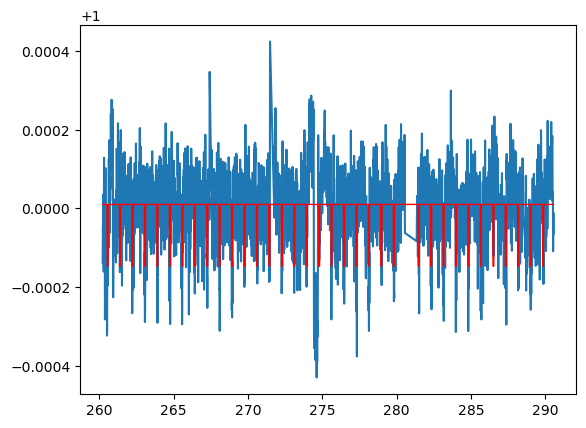

In [10]:
# what does that model look like?
model = bls.model(our_lc.time, best_period, best_duration, t0)
plt.plot(our_lc.time.value, our_lc.flux.value)
plt.plot(our_lc.time.value, model, color='red', lw=1)

Text(0.35, -0.00031383340219341395, 'Best Depth: 157 ppm')

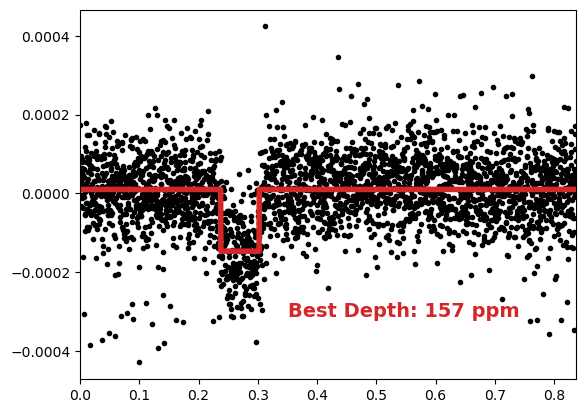

In [11]:
# fold it
folded_lc = our_lc.fold(period=best_period, t0=t0)

folded_times = our_lc.time.value % best_period.value
folded_args = np.argsort(folded_times)

plt.plot(folded_times[folded_args],our_lc.flux.value[folded_args]-1,'.k')
plt.plot(folded_times[folded_args],model[folded_args]-1,color='C3',lw=4)
plt.xlim(0, best_period.value)
plt.text(0.35, -best_depth*2, f'Best Depth: {best_depth*1e6:.0f} ppm',color='C3',fontdict={'size':14,'weight':'bold'})

In [12]:
# what is Rp/Rs?
print(f'Rp/R* =  {(best_depth.value)**0.5 * 100:.2f} %')
# Earth for comparison is 0.00916794
print(f'Earth/Sun Radius =  {0.00916794 * 100:.2f} %')

Rp/R* =  1.25 %
Earth/Sun Radius =  0.92 %


Now let's look at how it was in K2: where the systematics are terrible! Let's look at my favourite star, EPIC 212521166.

In [13]:
k2target = 'EPIC 212521166'
search = lightkurve.search_lightcurvefile(k2target)
search

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,K2 Campaign 06,2015,K2,1800,ktwo212521166,0.0
1,K2 Campaign 17,2018,K2,60,ktwo212521166,0.0
2,K2 Campaign 17,2018,K2,1800,ktwo212521166,0.0
3,K2 Campaign 06,2015,EVEREST,1800,ktwo212521166,0.0
4,K2 Campaign 06,2015,K2SC,1800,ktwo212521166,0.0
5,K2 Campaign 06,2015,K2SFF,1800,ktwo212521166,0.0
6,K2 Campaign 17,2018,EVEREST,1800,ktwo212521166,0.0
7,K2 Campaign 17,2018,K2SFF,1800,ktwo212521166,0.0


<Axes: xlabel='Time - 2454833 [BKJD days]', ylabel='Normalized Flux'>

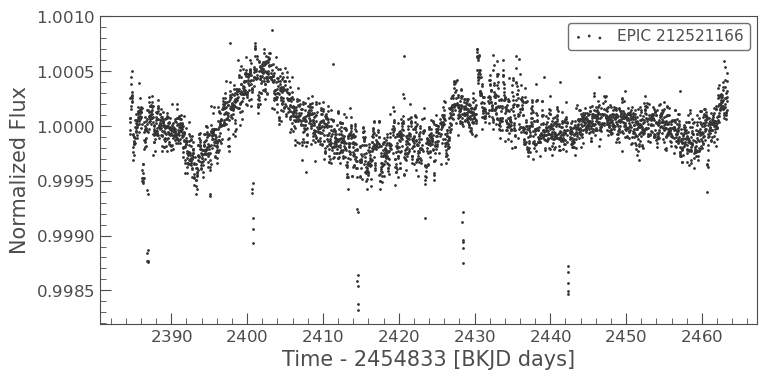

In [14]:
lc = search.download().PDCSAP_FLUX.normalize().remove_nans()
lc = lc[lc.quality==0]

lc.scatter()

Look at all those transits! But also look how it has a long-term variation, which is probably stellar, and a short term variation from the 6-hour pointing jitter of K2. We're going to correct for this by *detrending* with a Gaussian process.

Text(0, 0.5, 'Y')

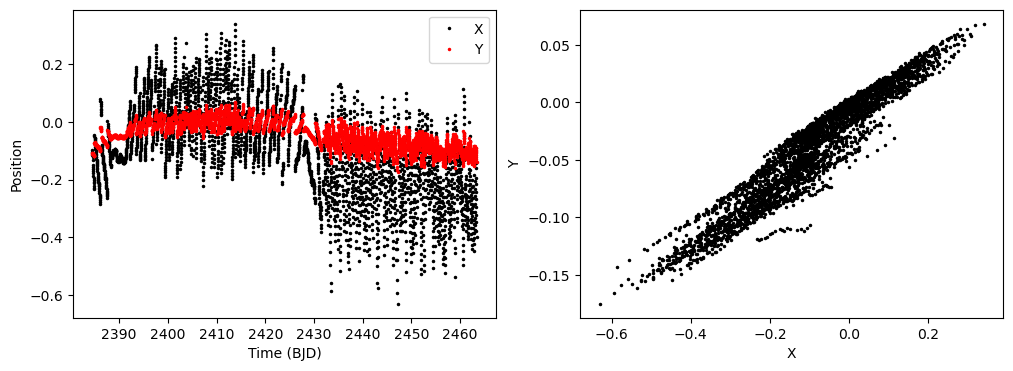

In [15]:
x, y = lc.pos_corr1, lc.pos_corr2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(lc.time.value, x, 'k.', markersize=3)
ax1.plot(lc.time.value, y, 'r.', markersize=3)
ax1.set_xlabel('Time (BJD)')
ax1.set_ylabel('Position')
ax1.legend(['X', 'Y'])

ax2.plot(x, y, '.k', markersize=3)
ax2.set_xlabel('X')
ax2.set_ylabel('Y')

In [16]:
lc.__class__ = k2sc_lc
lc.k2sc()

/Users/benpope/opt/anaconda3/envs/lk/lib/python3.11/site-packages/k2sc/standalone.py:293: LightkurveDeprecationWarning: The hdu function is deprecated and may be removed in a future version.
        Use fits.open(lc.filename) instead.
  primary_header = self.hdu[0].header
/Users/benpope/opt/anaconda3/envs/lk/lib/python3.11/site-packages/k2sc/standalone.py:293: ResourceWarning: unclosed file <_io.BufferedReader name='/Users/benpope/.lightkurve/cache/mastDownload/K2/ktwo212521166-c06_lc/ktwo212521166-c06_llc.fits'>
  primary_header = self.hdu[0].header
/Users/benpope/opt/anaconda3/envs/lk/lib/python3.11/site-packages/k2sc/standalone.py:294: LightkurveDeprecationWarning: The hdu function is deprecated and may be removed in a future version.
        Use fits.open(lc.filename) instead.
  data_header = self.hdu[1].header
/Users/benpope/opt/anaconda3/envs/lk/lib/python3.11/site-packages/k2sc/standalone.py:294: ResourceWarning: unclosed file <_io.BufferedReader name='/Users/benpope/.lightkurve

Using default splits [2390, 2428] for campaign 6
Starting initial outlier detection
  Flagged 34 ( 1.0%) outliers.
Starting Lomb-Scargle period search
  Using SqrExp position kernel
  Found periodicity p =   14.79 (fap 1.7550e-190 < 1e-50), will use a quasiperiodic kernel
Starting global hyperparameter optimisation using DE


 21%|██▏       | 32/150 [05:05<18:45,  9.54s/it, -ln(L)=-6003.2] 


  DE finished in 305 seconds
  DE minimum found at: [-5.754  0.93  15.435  0.024 -5.523  7.603 21.72  -4.036]
  DE -ln(L) -6003.2
Starting local hyperparameter optimisation
  Local minimum found at: [-6.000e+00  9.601e-01  1.322e+01  6.401e-03 -5.583e+00  6.214e+00
  2.650e+01 -4.039e+00]
Starting final outlier detection
      8 too high
     31 too low
      0 not finite
Computing time and position trends


/Users/benpope/opt/anaconda3/envs/lk/lib/python3.11/site-packages/k2sc/cdpp.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  f_sm[i] = p[j]


  CDPP - raw - 59.783
  CDPP - position component removed - 25.189
  CDPP - full reduction - 25.185
Detrending time 348.540424823761


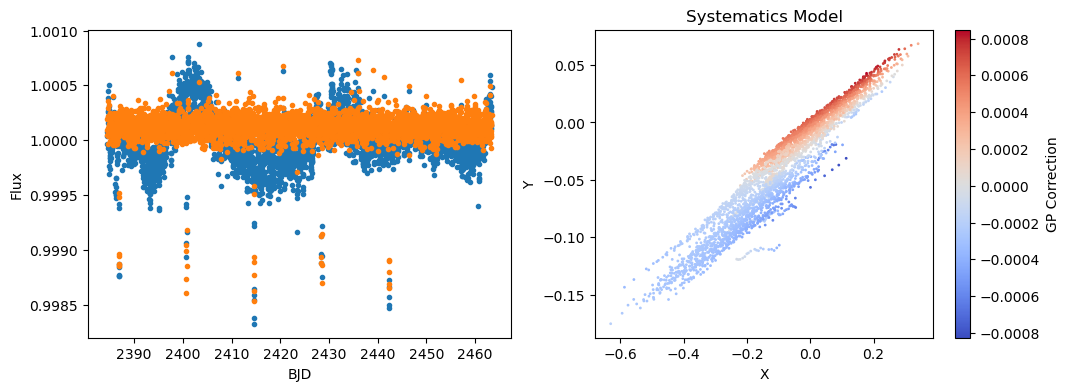

In [32]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12.0,4.0))

detrended = lc.corr_flux-lc.tr_time + np.nanmedian(lc.tr_time)
ax1.plot(lc.time.value,lc.flux.value,'.',label="Uncorrected")
ax1.plot(lc.time.value,detrended.value,'.',label="K2SC")
ax1.set_xlabel('BJD')
ax1.set_ylabel('Flux')

im = ax2.scatter(x,y,c=lc.tr_position-1,cmap='coolwarm',s=1)
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_title('Systematics Model')
plt.colorbar(im,label='GP Correction')


In [33]:
# search the detrended light curve for transits

bls = BoxLeastSquares(lc.time, detrended, dy=lc.flux_err)

periods = np.linspace(5, 20, 1000)*u.day
durations = np.linspace(0.05, 0.2, 10)*u.day
periodogram = bls.power(periods, durations)

best_period = periods[np.argmax(periodogram.depth_snr.value)]
best_duration = periodogram.duration[np.argmax(periodogram.depth_snr.value)]
best_depth = periodogram.depth[np.argmax(periodogram.depth_snr.value)]
t0 = periodogram.transit_time[np.argmax(periodogram.depth_snr.value)]

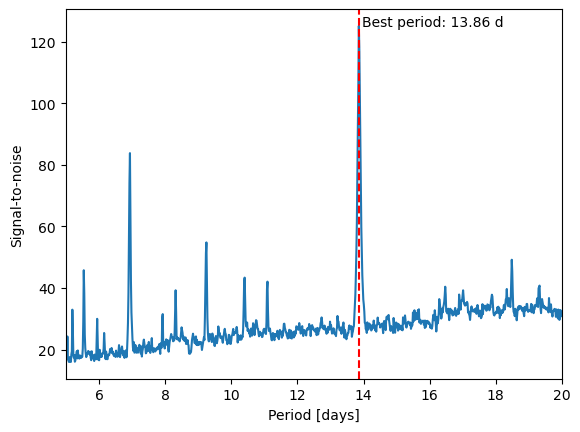

In [34]:
plt.plot(periodogram.period.value,periodogram.depth_snr.value)
plt.xlabel('Period [days]') 
plt.ylabel('Signal-to-noise')
plt.xlim(periods.min().value, periods.max().value)
plt.axvline(best_period.value, color='red', linestyle='dashed')
plt.text(best_period.value+0.1, np.max(periodogram.depth_snr.value), f'Best period: {best_period.value:.4g} d')
plt.show()

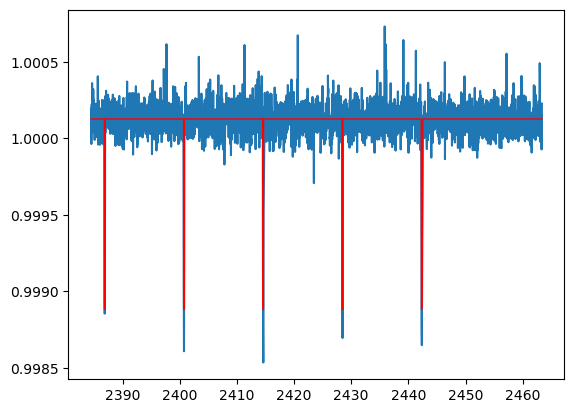

In [35]:
# what does the model look like?
model = bls.model(lc.time, best_period, best_duration, t0)
plt.plot(lc.time.value, detrended.value)
plt.plot(lc.time.value, model, color='red', lw=1)

In [16]:
# folded
folded_lc = lc.fold(period=best_period, t0=t0)

folded_times = lc.time.value % best_period.value
folded_args = np.argsort(folded_times)

plt.plot(folded_times[folded_args],detrended.value[folded_args]-1,'.k')
plt.plot(folded_times[folded_args],model[folded_args]-1,color='C3',lw=2)
plt.xlim(2,4)

NameError: name 'detrended' is not defined

How did we do this in the paper?

![EPIC 212521166](./epic212521166.jpeg)

Now let's look at one last dataset - some asteroseismology data from TESS. Let's look at the Northern Star - Polaris. "As constant as the Northern Star" - but is it really?

In [37]:
starname = 'Polaris'

search = lightkurve.search_lightcurvefile(starname,mission='TESS',exptime=120)
search

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 19,2019,SPOC,120,303256075,0.0
1,TESS Sector 60,2022,SPOC,120,303256075,0.0


In [38]:
polaris = search[0].download().PDCSAP_FLUX.normalize().remove_nans()

<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Normalized Flux'>

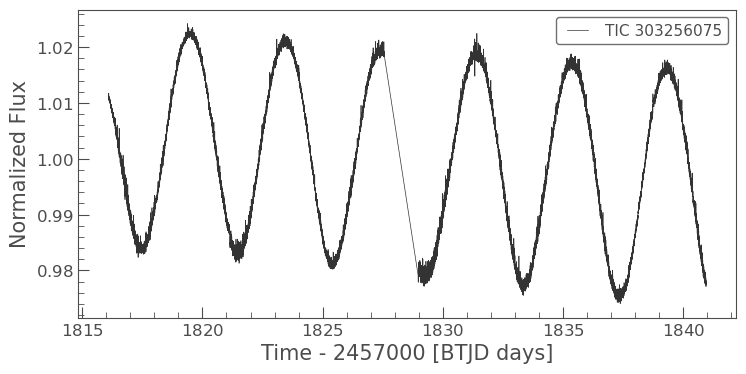

In [39]:
polaris.plot()

This is a typical light curve for a Cepheid variable! If we want to determine its period, we can use the Lomb-Scargle periodogram.

This is defined as:

$$P(f) = \frac{1}{2\sigma^2} \left( \left( \sum_i y_i \cos(2\pi f t_i) \right)^2 + \left( \sum_i y_i \sin(2\pi f t_i) \right)^2 \right)$$

where $y_i$ are the data points, $t_i$ are the times, and $\sigma$ is the standard deviation of the data.


This is an estimator for the mod-squared Fourier transform suitable for unevenly sampled data. In practice, this is implemented as a linear regression problem with a design matrix that includes sine and cosine terms at a single frequency for all times, and a mean term (and indeed polynomial trends or instrumental systematics models). 


Design matrix $X$:

$$X = \begin{bmatrix} 1 & \cos(2\pi f t_1) & \sin(2\pi f t_1) \\ 1 & \cos(2\pi f t_2) & \sin(2\pi f t_2) \\ \vdots & \vdots & \vdots \\ 1 & \cos(2\pi f t_N) & \sin(2\pi f t_N) \end{bmatrix}$$

We then solve this with least squares.

In [40]:
# lomb-scargle
ls = LombScargle(polaris.time, polaris.flux, dy=polaris.flux_err)
periods = np.linspace(1, 10, 1000)*u.day
frequency = 1/periods
power = ls.power(1/periods)

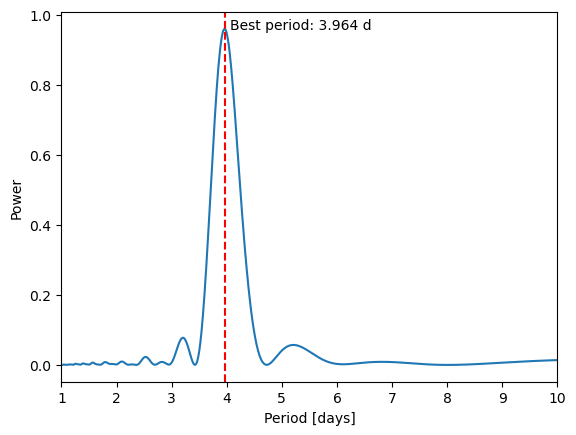

In [41]:
plt.plot(periods, power)
plt.xlabel('Period [days]')
plt.ylabel('Power')
plt.xlim(periods.min().value, periods.max().value)
plt.axvline(periods[np.argmax(power)].value, color='red', linestyle='dashed')
plt.text(periods[np.argmax(power)].value+0.1, np.max(power), f'Best period: {periods[np.argmax(power)].value:.4g} d');

In [45]:
test = lightkurve.search_lightcurve('del Sct')
test

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 80,2024,SPOC,120,162499828,0.0


In [47]:
dsct = test[0].download().remove_nans().normalize()

Text(0.5, 1.0, 'δ Scuti')

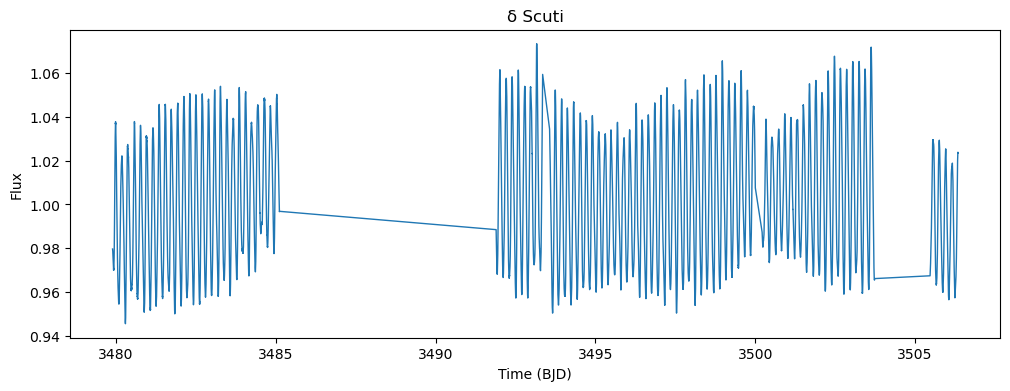

In [56]:
fig = plt.figure(figsize=(12,4))
plt.plot(dsct.time.value, dsct.flux.value,lw=1)
plt.xlabel('Time (BJD)')
plt.ylabel('Flux')

plt.title('δ Scuti')

Text(0.5, 1.0, 'δ Scuti')

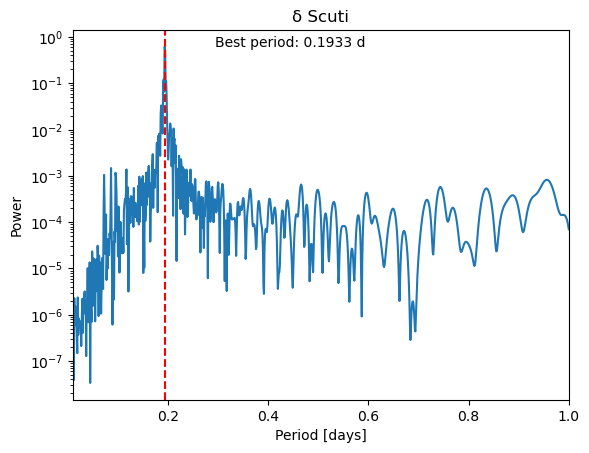

In [53]:
# lomb-scargle
ls = LombScargle(dsct.time, dsct.flux, dy=dsct.flux_err)

periods = np.linspace(0.01, 1, 1000)*u.day
frequency = 1/periods
power = ls.power(1/periods)

plt.plot(periods, power)
plt.xlabel('Period [days]')
plt.ylabel('Power')
plt.xlim(periods.min().value, periods.max().value)
plt.axvline(periods[np.argmax(power)].value, color='red', linestyle='dashed')
plt.text(periods[np.argmax(power)].value+0.1, np.max(power), f'Best period: {periods[np.argmax(power)].value:.4g} d');
plt.yscale('log')
plt.title('δ Scuti')

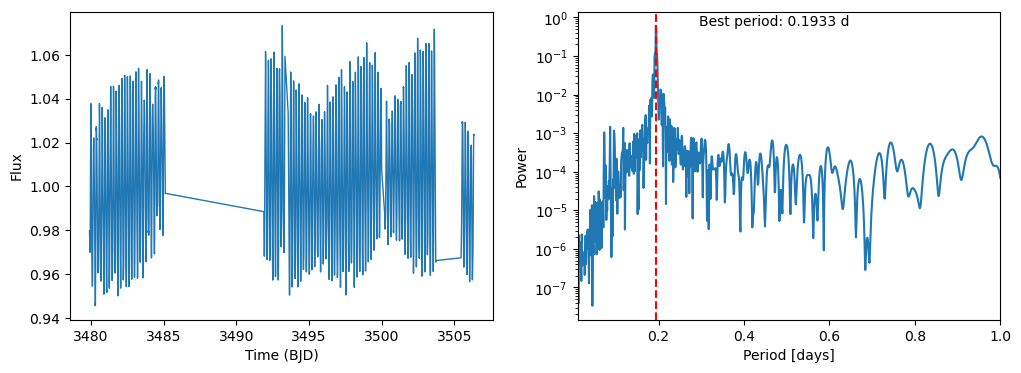

In [57]:
# both lc and periodogram
# use mosaic so they have ratio 2:1 width

# mosaic


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(dsct.time.value, dsct.flux.value, lw=1)
ax1.set_xlabel('Time (BJD)')
ax1.set_ylabel('Flux')

ax2.plot(periods, power)
ax2.set_xlabel('Period [days]')
ax2.set_ylabel('Power')
ax2.set_xlim(periods.min().value, periods.max().value)
ax2.axvline(periods[np.argmax(power)].value, color='red', linestyle='dashed')
ax2.text(periods[np.argmax(power)].value+0.1, np.max(power), f'Best period: {periods[np.argmax(power)].value:.4g} d')
ax2.set_yscale('log')


Text(0.5, 0.98, 'δ Scuti')

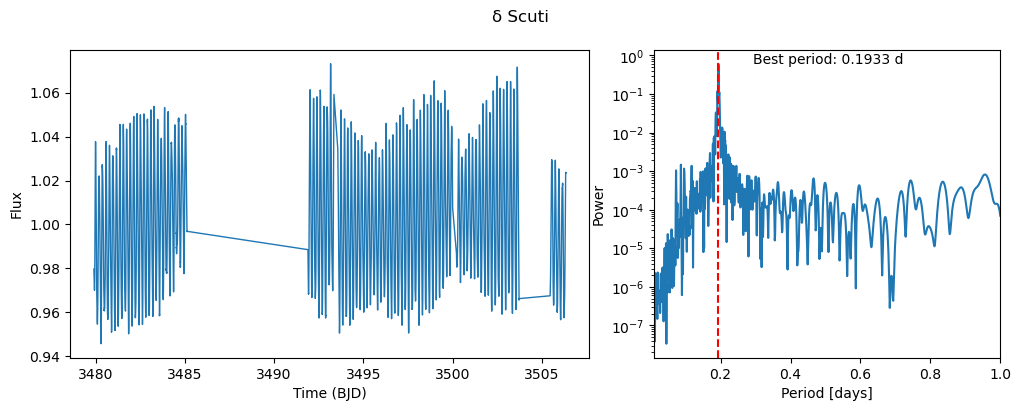

In [69]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(12, 4))
# Create a gridspec with a 2:1 width ratio
gs = gridspec.GridSpec(1, 2, width_ratios=[1.5, 1])

# Create subplots using the gridspec
ax1 = plt.subplot(gs[0])
ax2 = plt.subplot(gs[1])

# Plot the data on the subplots
ax1.plot(dsct.time.value, dsct.flux.value, lw=1)
ax1.set_xlabel('Time (BJD)')
ax1.set_ylabel('Flux')

ax2.plot(periods, power)
ax2.set_xlabel('Period [days]')
ax2.set_ylabel('Power')
ax2.set_xlim(periods.min().value, periods.max().value)
ax2.axvline(periods[np.argmax(power)].value, color='red', linestyle='dashed')
ax2.text(periods[np.argmax(power)].value+0.1, np.max(power), f'Best period: {periods[np.argmax(power)].value:.4g} d')
ax2.set_yscale('log')

# Adjust the spacing between subplots
plt.subplots_adjust(wspace=0.15)

plt.suptitle('δ Scuti')

In [71]:
# now do the same for gamma Dor

test = lightkurve.search_lightcurve('gamma Dor',exptime=120,mission='TESS',author='SPOC')    
test


#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 03,2018,SPOC,120,219234987,0.0
1,TESS Sector 04,2018,SPOC,120,219234987,0.0
2,TESS Sector 05,2018,SPOC,120,219234987,0.0
3,TESS Sector 30,2020,SPOC,120,219234987,0.0
4,TESS Sector 31,2020,SPOC,120,219234987,0.0
5,TESS Sector 32,2020,SPOC,120,219234987,0.0


In [72]:
gdor = test[0:2].download_all().stitch().remove_nans().normalize()



Text(0.5, 1.0, 'δ Scuti')

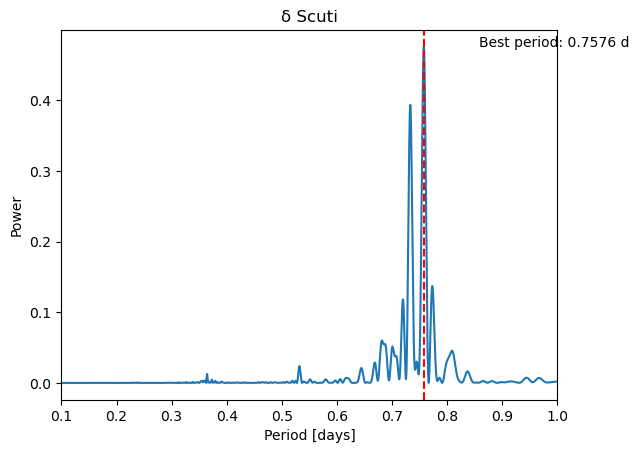

In [84]:
# ls 
ls = LombScargle(gdor.time, gdor.flux, dy=gdor.flux_err)

periods = np.linspace(0.1, 1, 10000)*u.day
frequency = 1/periods
power = ls.power(1/periods)

plt.plot(periods, power)
plt.xlabel('Period [days]')
plt.ylabel('Power')
plt.xlim(periods.min().value, periods.max().value)
plt.axvline(periods[np.argmax(power)].value, color='red', linestyle='dashed')
plt.text(periods[np.argmax(power)].value+0.1, np.max(power), f'Best period: {periods[np.argmax(power)].value:.4g} d');
plt.title('δ Scuti')

Text(0.5, 0.98, 'γ Doradus')

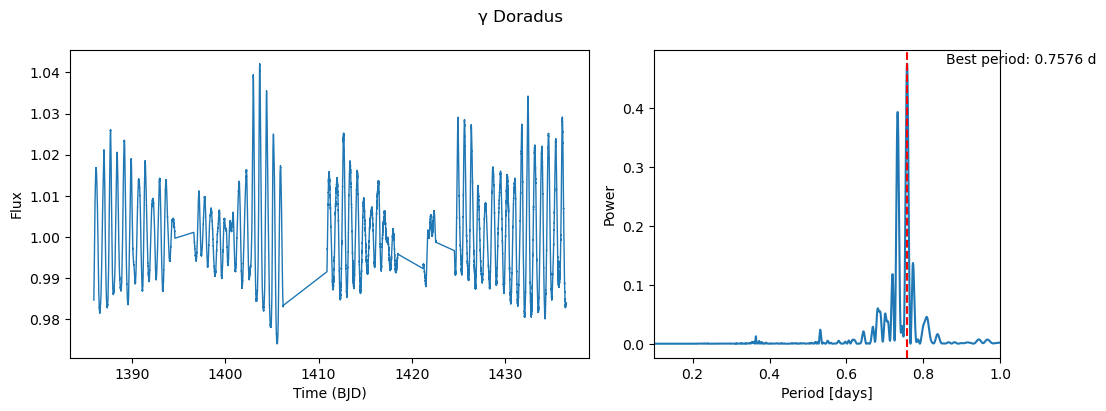

In [85]:

fig = plt.figure(figsize=(12, 4))
# Create a gridspec with a 2:1 width ratio
gs = gridspec.GridSpec(1, 2, width_ratios=[1.5, 1])

# Create subplots using the gridspec
ax1 = plt.subplot(gs[0])
ax2 = plt.subplot(gs[1])

# Plot the data on the subplots
ax1.plot(gdor.time.value, gdor.flux.value, lw=1)
ax1.set_xlabel('Time (BJD)')
ax1.set_ylabel('Flux')

ax2.plot(periods, power)
ax2.set_xlabel('Period [days]')
ax2.set_ylabel('Power')
ax2.set_xlim(periods.min().value, periods.max().value)
ax2.axvline(periods[np.argmax(power)].value, color='red', linestyle='dashed')
ax2.text(periods[np.argmax(power)].value+0.1, np.max(power), f'Best period: {periods[np.argmax(power)].value:.4g} d')

# Adjust the spacing between subplots
plt.subplots_adjust(wspace=0.15)

plt.suptitle('γ Doradus')

In [87]:
search = lightkurve.search_lightcurve('TIC 308396022',mission='TESS',exptime=120,author='SPOC')
search

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 01,2018,SPOC,120,308396022,0.0
1,TESS Sector 04,2018,SPOC,120,308396022,0.0
2,TESS Sector 05,2018,SPOC,120,308396022,0.0
3,TESS Sector 07,2019,SPOC,120,308396022,0.0
4,TESS Sector 08,2019,SPOC,120,308396022,0.0
5,TESS Sector 09,2019,SPOC,120,308396022,0.0
6,TESS Sector 10,2019,SPOC,120,308396022,0.0
7,TESS Sector 11,2019,SPOC,120,308396022,0.0
8,TESS Sector 28,2020,SPOC,120,308396022,0.0


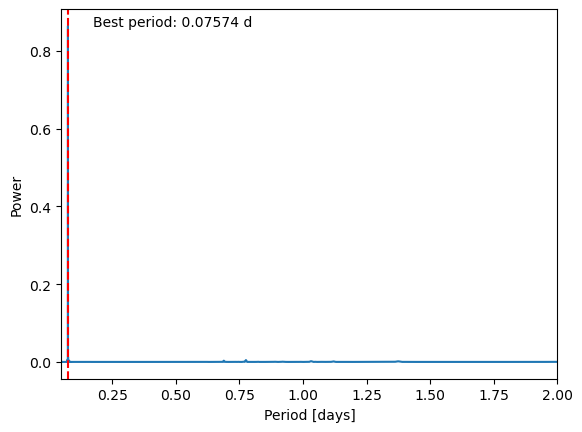

In [89]:
hybrid = search[3:7].download_all().stitch().remove_nans().normalize()

ls = LombScargle(hybrid.time, hybrid.flux, dy=hybrid.flux_err)

periods = np.linspace(0.05, 2, 10000)*u.day

frequency = 1/periods
power = ls.power(1/periods)


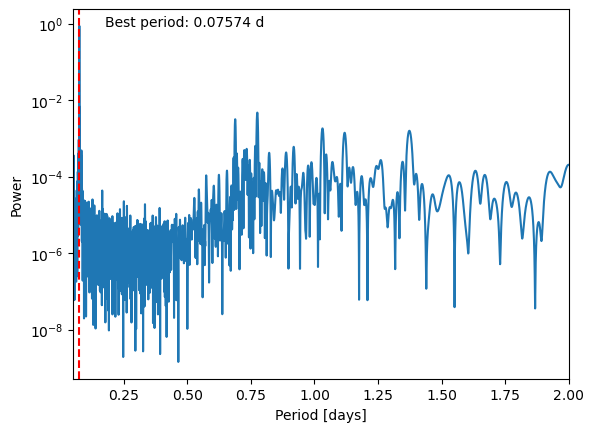

In [90]:

plt.plot(periods, power)
plt.xlabel('Period [days]')
plt.ylabel('Power')
plt.xlim(periods.min().value, periods.max().value)
plt.axvline(periods[np.argmax(power)].value, color='red', linestyle='dashed')
plt.yscale('log')
plt.text(periods[np.argmax(power)].value+0.1, np.max(power), f'Best period: {periods[np.argmax(power)].value:.4g} d');

Text(0.5, 0.98, 'δ Sct / γ Dor Hybrid TIC 308396022')

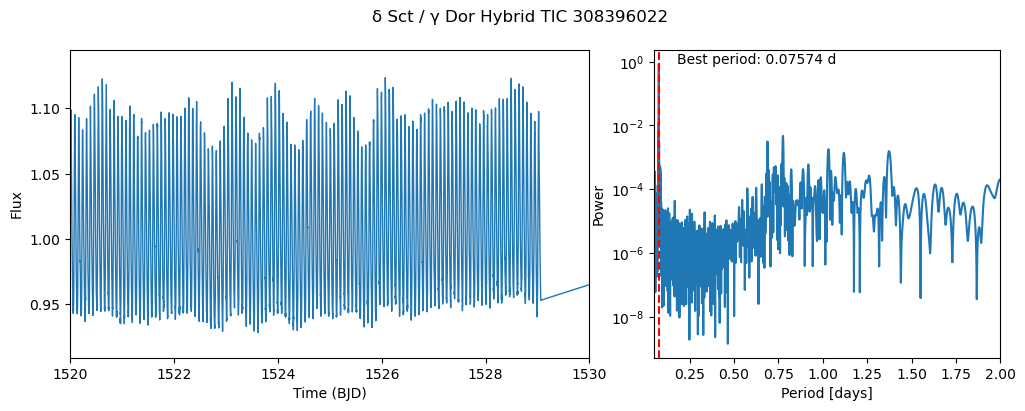

In [94]:

fig = plt.figure(figsize=(12, 4))
# Create a gridspec with a 2:1 width ratio
gs = gridspec.GridSpec(1, 2, width_ratios=[1.5, 1])

# Create subplots using the gridspec
ax1 = plt.subplot(gs[0])
ax2 = plt.subplot(gs[1])

# Plot the data on the subplots
ax1.plot(hybrid.time.value, hybrid.flux.value, lw=1)
ax1.set_xlabel('Time (BJD)')
ax1.set_ylabel('Flux')
ax1.set_xlim(1520,1530)

ax2.plot(periods, power)
ax2.set_xlabel('Period [days]')
ax2.set_ylabel('Power')
ax2.set_xlim(periods.min().value, periods.max().value)
ax2.axvline(periods[np.argmax(power)].value, color='red', linestyle='dashed')
ax2.text(periods[np.argmax(power)].value+0.1, np.max(power), f'Best period: {periods[np.argmax(power)].value:.4g} d')
ax2.set_yscale('log')
# Adjust the spacing between subplots
plt.subplots_adjust(wspace=0.15)

plt.suptitle('δ Sct / γ Dor Hybrid TIC 308396022')